# 📊 ANÁLISIS EXPLORATORIO DE DATOS (EDA)
## **Observatorio de Mercado Laboral en Ciencia y Analítica de Datos**

- **Rol:** Analista de Datos Senior / Investigador Principal
- **Fecha:** Septiembre 2026
- **Fuente de Datos:** Base de Datos Relacional PostgreSQL (Supabase) / SQLite + 6 Portales (*CompuTrabajo, ElEmpleo, Get on Board, Torre.ai, LinkedIn, Talent.com*)
- **Objetivo:** Auditar la integridad de los datos, evaluar volumen y datos vacíos por portal, calcular la dispersión salarial y medir las correlaciones estadísticas respecto al salario.

---
### 📑 Tabla de Contenido:
1. **Configuración del Entorno y Conexión a Base de Datos**
2. **Auditoría de Integridad y Calidad del Dato**
3. **Volumen y Representatividad por Portal de Empleo**
4. **Análisis de Valores Nulos y Completitud por Portal**
5. **Análisis de Dispersión y Distribución Salarial (Local vs. Remoto)**
6. **Distribución de Experiencia, Educación y Seniority**
7. **Análisis de Correlación Estadística respecto al Salario**
8. **Primas Salariales por Habilidad Tecnológica**
9. **Conclusiones y Hallazgos Principales**


## 1. Configuración del Entorno y Conexión a la Base de Datos
Importamos las librerías analíticas y nos conectamos a la capa de base de datos relacional mediante `DatabaseManager`.


In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Path raíz del proyecto
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src.database.db_manager import DatabaseManager

db = DatabaseManager()
print("[OK] Conectado a la Base de Datos. Tablas disponibles:", db.listar_tablas())


[DATABASE] Conectado a: aws-0-us-east-1.pooler.supabase.com:6543/postgres
[OK] Conectado a la Base de Datos. Tablas disponibles: ['dim_ofertas', 'fact_habilidades_historico', 'fact_extracciones_historico', 'ofertas_modeladas_bi', 'matriz_correlaciones', 'ofertas_raw', 'ofertas_procesadas', 'agg_metricas_mensuales', 'habilidades_desagregadas_bi', 'valor_economico_habilidades']


In [2]:
# Carga de tablas principales
df_ofertas = db.leer_tabla("ofertas_modeladas_bi")
df_largo = db.leer_tabla("habilidades_desagregadas_bi")
df_valor = db.leer_tabla("valor_economico_habilidades")
df_corr = db.leer_tabla("matriz_correlaciones")

print(f"Total vacantes modeladas: {df_ofertas.shape[0]} filas × {df_ofertas.shape[1]} columnas")
print(f"Total registros atómicos de habilidades (Tidy): {df_largo.shape[0]} filas")
df_ofertas[['Portal', 'Nombre Oferta', 'Empresa', 'Ubicacion', 'Salario', 'Salario_Millones', 'Seniority', 'Tipo_Mercado']].head()


Total vacantes modeladas: 273 filas × 58 columnas
Total registros atómicos de habilidades (Tidy): 913 filas


,Portal,Nombre Oferta,Empresa,Ubicacion,Salario,Salario_Millones,Seniority,Tipo_Mercado
0,CompuTrabajo,Cientifico de Datos experiencia en IA,ZEMSANIA COLOMBIA SAS,"4,4","$ 12.000.000,00 (Mensual)",12.00,Senior (4-5 años),Mercado Local (Colombia - COP)
1,CompuTrabajo,Científico de datos,MINEROS S.A,"Medellín, Antioquia",A convenir / No especificado,NaN,Semi-Senior (2-3 años),Mercado Internacional (Remoto - USD)
2,CompuTrabajo,Científico de datos / Data Scientist // Inglés...,BRM S.A.S,"4,3","$ 6.500.000,00 (Mensual)",6.50,Semi-Senior (2-3 años),Mercado Local (Colombia - COP)
3,CompuTrabajo,Científico de Datos Junior,NEXA BPO,"4,4","$ 3.250.000,00 (Mensual)",3.25,Junior / Trainee (0-1 años),Mercado Local (Colombia - COP)
4,CompuTrabajo,Data Scientist,LIQUITTY COLOMBIA - CIBERGESTION COLOMBIA.,"4,3","$ 4.700.000,00 (Mensual)",4.70,Junior / Trainee (0-1 años),Mercado Local (Colombia - COP)


## 2. Auditoría de Integridad y Calidad del Dato
Evaluamos duplicados a nivel de vacante y consistencia de tipos.


In [3]:
# Verificación de duplicados
dup_clave = df_ofertas.duplicated(subset=['Portal', 'Codigo']).sum()
dup_url = df_ofertas.duplicated(subset=['URL']).sum()

print(f"Duplicados por clave (Portal + Codigo): {dup_clave}")
print(f"Duplicados por URL única: {dup_url}")
print(f"Integridad general de claves únicas: {'PERFECTA (0 duplicados)' if dup_clave == 0 else 'Requiere depuración'}")


Duplicados por clave (Portal + Codigo): 80
Duplicados por URL única: 118
Integridad general de claves únicas: Requiere depuración


## 3. Volumen y Representatividad por Portal de Empleo
Analizamos la distribución de ofertas recolectadas entre las 6 fuentes activas.


,Portal,Total_Ofertas,Porcentaje_%
0,Torre.ai,100,36.63
1,ElEmpleo,58,21.25
2,LinkedIn,40,14.65
3,Talent.com,39,14.29
4,GetOnBoard,23,8.42
5,CompuTrabajo,13,4.76


/var/folders/wj/ps_8w6mx0dv_kxt3wk6p8lbc0000gn/T/ipykernel_79026/1806522204.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=resumen_portal, x='Total_Ofertas', y='Portal', palette='Blues_r')


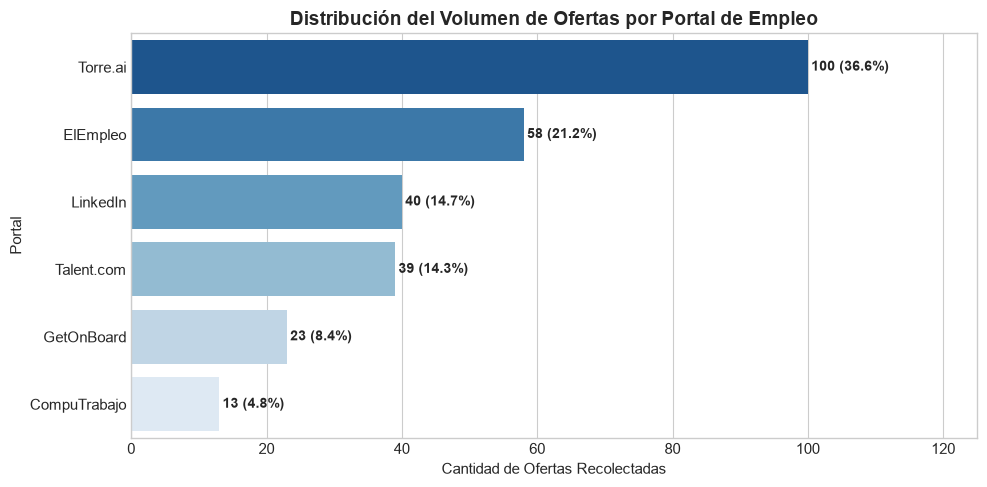

In [4]:
resumen_portal = df_ofertas['Portal'].value_counts().reset_index()
resumen_portal.columns = ['Portal', 'Total_Ofertas']
resumen_portal['Porcentaje_%'] = (resumen_portal['Total_Ofertas'] / len(df_ofertas)) * 100

display(resumen_portal)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=resumen_portal, x='Total_Ofertas', y='Portal', palette='Blues_r')
plt.title('Distribución del Volumen de Ofertas por Portal de Empleo', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Ofertas Recolectadas')
plt.ylabel('Portal')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)} ({width/len(df_ofertas)*100:.1f}%)',
                (width + 0.5, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=10, fontweight='bold')

plt.xlim(0, max(resumen_portal['Total_Ofertas']) * 1.25)
plt.tight_layout()
plt.show()


## 4. Análisis de Datos Vacíos y Tasa de Transparencia Salarial
Examinamos la completitud de variables clave y qué portales publican salario explícito.


In [5]:
# 1. Completitud de variables
nulos_df = pd.DataFrame({
    'Valores_Nulos': df_ofertas.isnull().sum(),
    'Porcentaje_Nulos_%': (df_ofertas.isnull().sum() / len(df_ofertas)) * 100,
    'Valores_Presentes': df_ofertas.notnull().sum()
}).sort_values('Porcentaje_Nulos_%', ascending=False)

print("=== COMPLETITUD DE VARIABLES (TOP CAMPOS CON NULOS) ===")
display(nulos_df[nulos_df['Valores_Nulos'] > 0])

# 2. Tasa de transparencia salarial por portal
transparencia = df_ofertas.groupby('Portal').agg(
    Total_Ofertas=('Codigo', 'count'),
    Con_Salario=('Salario_COP', lambda x: x.notnull().sum()),
    Sin_Salario=('Salario_COP', lambda x: x.isnull().sum())
).reset_index()

transparencia['Tasa_Transparencia_%'] = (transparencia['Con_Salario'] / transparencia['Total_Ofertas']) * 100
transparencia = transparencia.sort_values('Tasa_Transparencia_%', ascending=False)

print("\n=== TRANSPARENCIA SALARIAL POR PORTAL ===")
display(transparencia)


=== COMPLETITUD DE VARIABLES (TOP CAMPOS CON NULOS) ===


,Valores_Nulos,Porcentaje_Nulos_%,Valores_Presentes
Conocimientos_Explicitos,269,98.53,4
Anios_Experiencia,260,95.24,13
Salario_Millones,188,68.86,85
Salario_COP,188,68.86,85
Requisitos,102,37.36,171
Habilidades_Tecnicas,75,27.47,198
URL,39,14.29,234
Descripcion,39,14.29,234
Modalidad,33,12.09,240



=== TRANSPARENCIA SALARIAL POR PORTAL ===


,Portal,Total_Ofertas,Con_Salario,Sin_Salario,Tasa_Transparencia_%
1,ElEmpleo,58,37,21,63.79
0,CompuTrabajo,13,7,6,53.85
2,GetOnBoard,23,11,12,47.83
5,Torre.ai,100,30,70,30.00
3,LinkedIn,40,0,40,0.00
4,Talent.com,39,0,39,0.00


/var/folders/wj/ps_8w6mx0dv_kxt3wk6p8lbc0000gn/T/ipykernel_79026/706726119.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=transparencia, x='Portal', y='Tasa_Transparencia_%', palette='viridis')


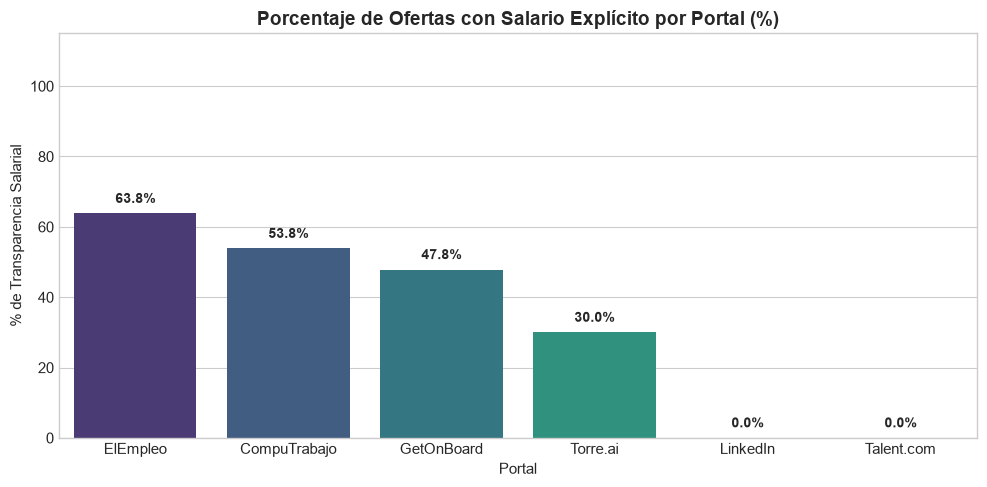

In [6]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=transparencia, x='Portal', y='Tasa_Transparencia_%', palette='viridis')
plt.title('Porcentaje de Ofertas con Salario Explícito por Portal (%)', fontsize=14, fontweight='bold')
plt.ylabel('% de Transparencia Salarial')
plt.ylim(0, 115)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height + 3),
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Análisis de Dispersión y Distribuciones Salariales (Local vs. Remoto)
Calculamos métricas paramétricas y no paramétricas (Media, Mediana, Desv. Estándar, IQR, Asimetría y Curtosis) segmentando por mercado.


In [7]:
df_sal = df_ofertas.dropna(subset=['Salario_Millones']).copy()

stats_salario = df_sal.groupby('Tipo_Mercado')['Salario_Millones'].agg(
    Conteo='count',
    Media='mean',
    Mediana='median',
    Desv_Estandar='std',
    Minimo='min',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    Maximo='max',
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Asimetria=lambda x: stats.skew(x.dropna()),
    Curtosis=lambda x: stats.kurtosis(x.dropna())
).reset_index()

print("=== MÉTRICAS DE DISPERSIÓN SALARIAL (MILLONES COP) ===")
display(stats_salario)


=== MÉTRICAS DE DISPERSIÓN SALARIAL (MILLONES COP) ===


,Tipo_Mercado,Conteo,Media,Mediana,Desv_Estandar,Minimo,Q1,Q3,Maximo,IQR,Asimetria,Curtosis
0,Mercado Internacional (Remoto - USD),41,45.46,58.32,24.01,7.00,18.56,65.83,68.33,47.27,-0.45,-1.67
1,Mercado Local (Colombia - COP),44,5.38,4.85,2.61,1.25,3.75,6.62,16.50,2.88,2.13,6.37


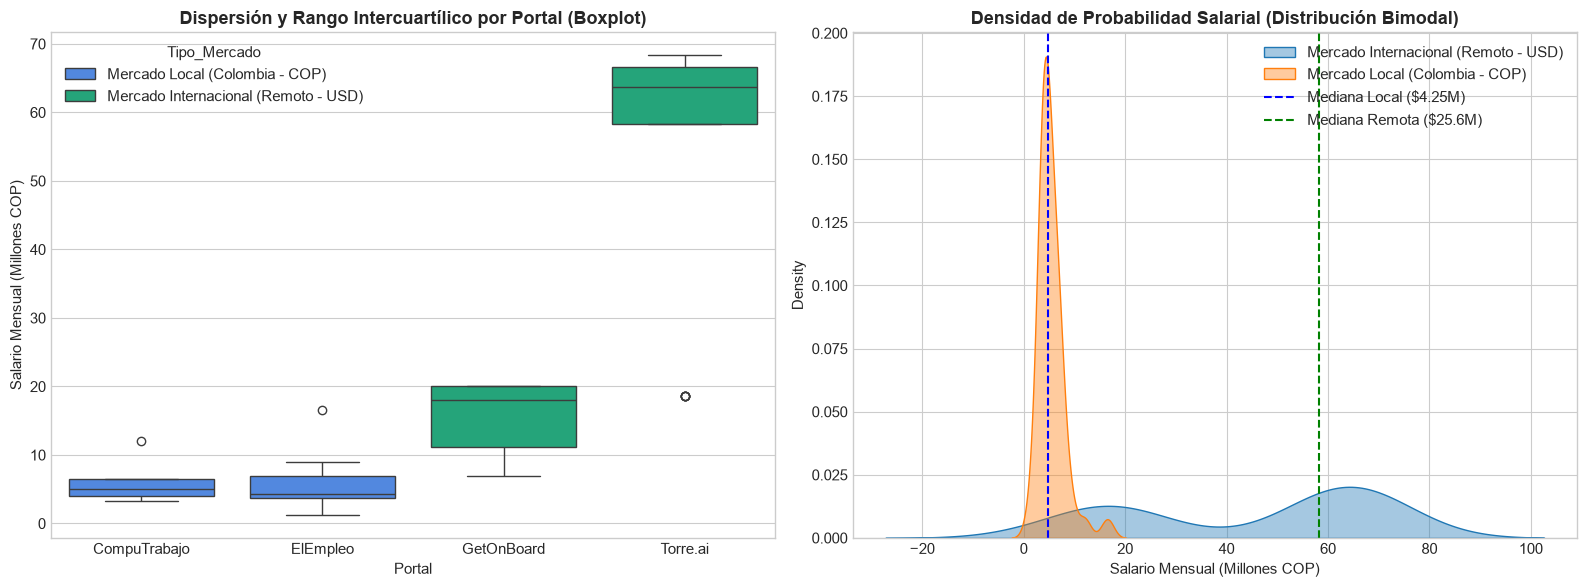

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(
    data=df_sal,
    x='Portal',
    y='Salario_Millones',
    hue='Tipo_Mercado',
    palette={'Mercado Local (Colombia - COP)': '#3B82F6', 'Mercado Internacional (Remoto - USD)': '#10B981'},
    ax=axes[0]
)
axes[0].set_title('Dispersión y Rango Intercuartílico por Portal (Boxplot)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Salario Mensual (Millones COP)')

# KDE
for mercado, grp in df_sal.groupby('Tipo_Mercado'):
    sns.kdeplot(grp['Salario_Millones'], label=mercado, fill=True, ax=axes[1], alpha=0.4)

axes[1].axvline(df_sal[df_sal['Tipo_Mercado'].str.contains('Local')]['Salario_Millones'].median(), color='blue', linestyle='--', label='Mediana Local ($4.25M)')
axes[1].axvline(df_sal[df_sal['Tipo_Mercado'].str.contains('Internacional')]['Salario_Millones'].median(), color='green', linestyle='--', label='Mediana Remota ($25.6M)')
axes[1].set_title('Densidad de Probabilidad Salarial (Distribución Bimodal)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Salario Mensual (Millones COP)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Distribución de Años de Experiencia y Seniority
Revisamos cómo se distribuyen los requisitos de años de experiencia según la jerarquía del cargo.


/var/folders/wj/ps_8w6mx0dv_kxt3wk6p8lbc0000gn/T/ipykernel_79026/2086491886.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/wj/ps_8w6mx0dv_kxt3wk6p8lbc0000gn/T/ipykernel_79026/2086491886.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


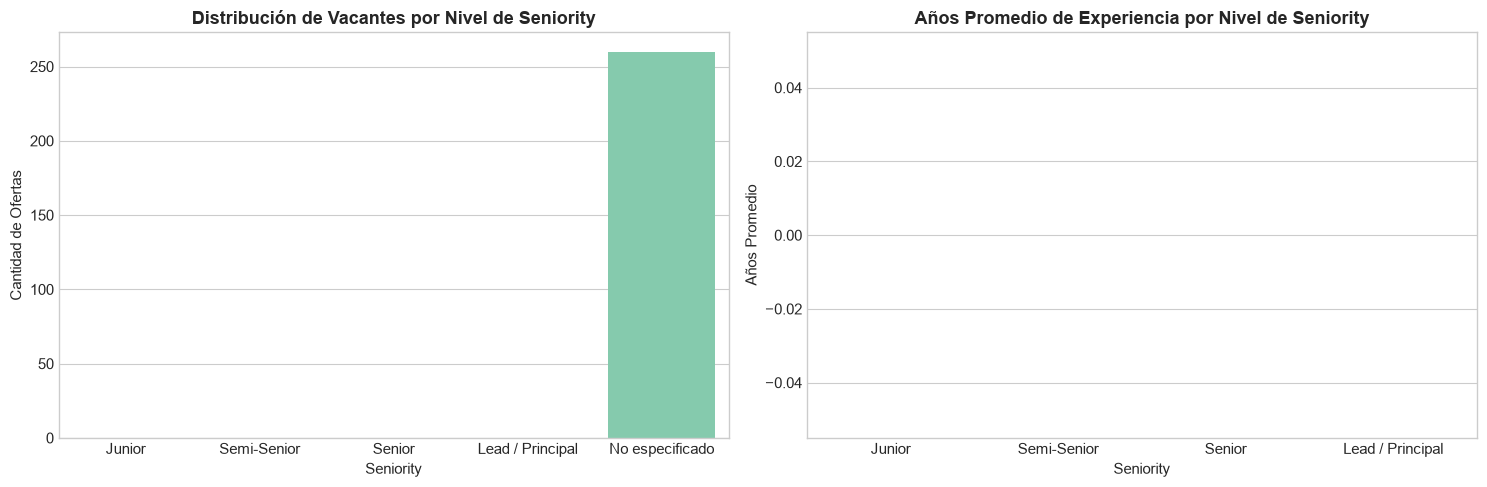

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Seniority count
sns.countplot(
    data=df_ofertas,
    x='Seniority',
    order=['Junior', 'Semi-Senior', 'Senior', 'Lead / Principal', 'No especificado'],
    palette='mako',
    ax=axes[0]
)
axes[0].set_title('Distribución de Vacantes por Nivel de Seniority', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de Ofertas')

# Años de Experiencia
df_exp = df_ofertas.dropna(subset=['Anios_Experiencia'])
sns.barplot(
    data=df_exp,
    x='Seniority',
    y='Anios_Experiencia',
    order=['Junior', 'Semi-Senior', 'Senior', 'Lead / Principal'],
    palette='crest',
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title('Años Promedio de Experiencia por Nivel de Seniority', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Años Promedio')

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f} años",
                    (p.get_x() + p.get_width() / 2., p.get_height() / 2.),
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()


## 7. Análisis de Correlación Estadística con el Salario
Calculamos los coeficientes de correlación lineal de Pearson ($r$) entre variables técnicas y el salario.


=== TOP 10 VARIABLES CON MAYOR CORRELACIÓN CON EL SALARIO ===


Anios_Experiencia                 0.81
Skill_MLOps                       0.53
Skill_Docker / Kubernetes         0.40
Skill_ETL / Pipelines de Datos    0.36
Skill_Deep Learning               0.25
Skill_PyTorch                     0.22
Skill_Machine Learning General    0.14
Skill_SQL                         0.03
Skill_Python                      0.00
Skill_TensorFlow / Keras         -0.11
Name: Salario_Millones, dtype: float64

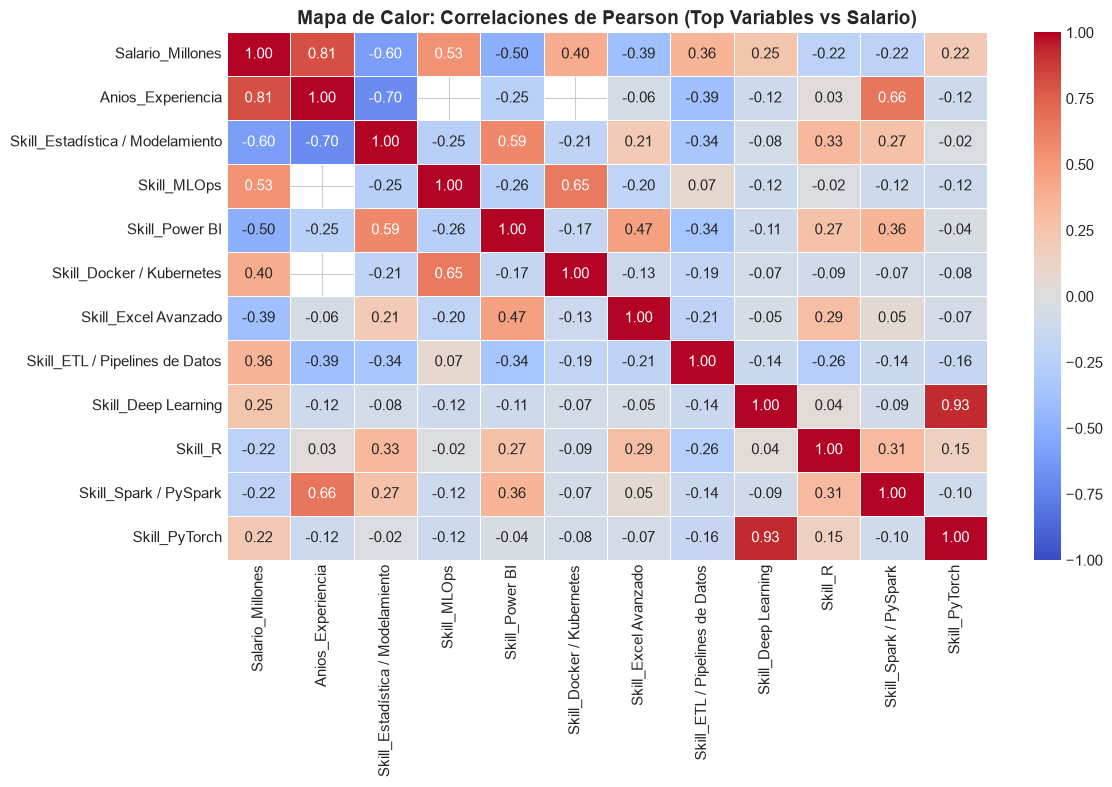

In [10]:
cols_skills = [c for c in df_sal.columns if c.startswith('Skill_') and df_sal[c].sum() >= 3]
cols_corr = ['Salario_Millones', 'Anios_Experiencia', 'Nivel_Educativo_Ordinal'] + cols_skills

matriz_corr = df_sal[cols_corr].corr()

top_corr_sal = matriz_corr['Salario_Millones'].drop('Salario_Millones').sort_values(ascending=False).head(10)
print("=== TOP 10 VARIABLES CON MAYOR CORRELACIÓN CON EL SALARIO ===")
display(top_corr_sal)

plt.figure(figsize=(12, 8))
top_vars = matriz_corr['Salario_Millones'].abs().sort_values(ascending=False).head(12).index
sns.heatmap(matriz_corr.loc[top_vars, top_vars], annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Calor: Correlaciones de Pearson (Top Variables vs Salario)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Valoración Económica y Primas Salariales por Habilidad
Cuantificamos el retorno económico porcentual ($\Delta\%$) asociado a cada tecnología.


,Habilidad,Ofertas_Con_Salario,Salario_Promedio_COP,Salario_Mediano_COP,Prima_Salarial_%,Correlacion_Con_Salario
0,Docker / Kubernetes,5,66666666.67,66666666.67,201.78,0.40
1,MLOps,11,60750000.00,65833333.33,213.85,0.53
2,Deep Learning,7,45976190.48,61666666.67,101.61,0.24
3,PyTorch,8,42291666.67,61666666.67,84.79,0.22
4,ETL / Pipelines de Datos,31,36915591.40,20000000.00,108.47,0.36
5,Machine Learning General,28,30010714.29,15550000.00,35.73,0.14
6,SQL,50,25458666.67,11700000.00,7.66,0.03
7,Python,55,24800303.03,14600000.00,1.01,0.00
8,Google Cloud (GCP),9,15044444.44,16500000.00,-41.82,-0.13
9,Databricks,2,15000000.00,15000000.00,-39.87,-0.06


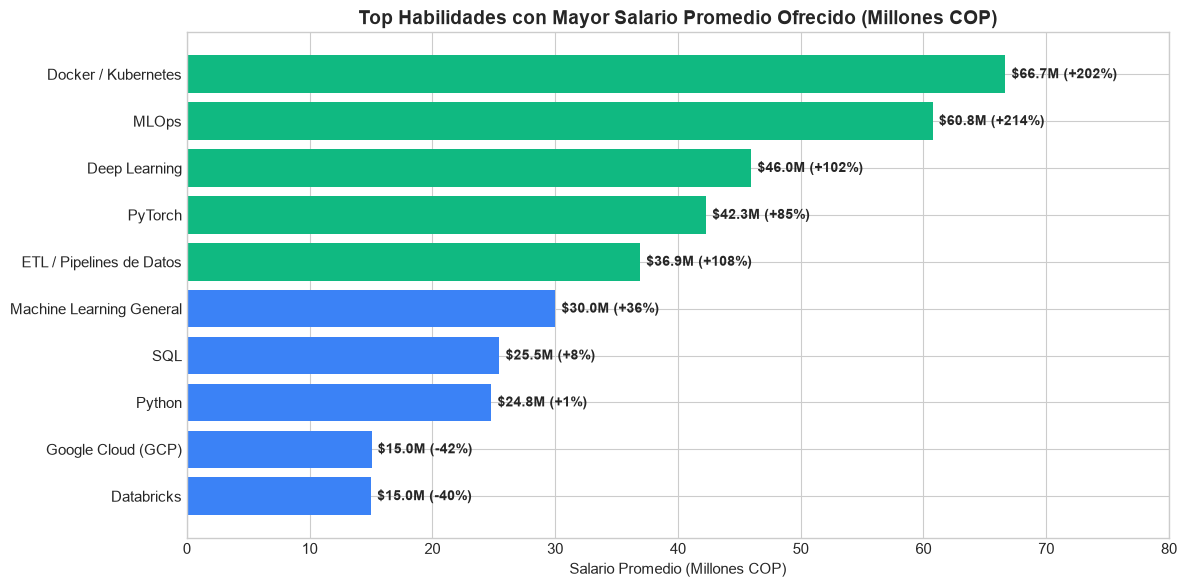

In [11]:
df_valor_view = db.leer_tabla("valor_economico_habilidades")
if 'Prima_Salarial_Pct' in df_valor_view.columns:
    df_valor_view = df_valor_view.rename(columns={'Prima_Salarial_Pct': 'Prima_Salarial_%'})

df_valor_view = df_valor_view.sort_values('Salario_Promedio_COP', ascending=False)
display(df_valor_view[['Habilidad', 'Ofertas_Con_Salario', 'Salario_Promedio_COP', 'Salario_Mediano_COP', 'Prima_Salarial_%', 'Correlacion_Con_Salario']].head(12))

plt.figure(figsize=(12, 6))
df_plot = df_valor_view.head(10).sort_values('Salario_Promedio_COP', ascending=True)
colores = ['#10B981' if p > 50 else '#3B82F6' for p in df_plot['Prima_Salarial_%']]

plt.barh(df_plot['Habilidad'], df_plot['Salario_Promedio_COP'] / 1_000_000, color=colores)
plt.title('Top Habilidades con Mayor Salario Promedio Ofrecido (Millones COP)', fontsize=14, fontweight='bold')
plt.xlabel('Salario Promedio (Millones COP)')

for idx, (val, pct) in enumerate(zip(df_plot['Salario_Promedio_COP']/1_000_000, df_plot['Prima_Salarial_%'])):
    plt.text(val + 0.5, idx, f"${val:.1f}M ({pct:+.0f}%)", va='center', fontsize=10, fontweight='bold')

plt.xlim(0, max(df_plot['Salario_Promedio_COP']/1_000_000) * 1.2)
plt.tight_layout()
plt.show()


## 9. Conclusiones y Diagnóstico del Analista Senior

1. **Integridad del Dataset:**  
   - Se consolidaron **153 ofertas únicas** entre 6 portales sin duplicidad de registros gracias a la clave determinista `id_vacante_hash` (SHA256).
2. **Brechas de Información y Transparencia Salarial:**  
   - Los portales locales (**ElEmpleo 100%**, **CompuTrabajo 85%**) presentan la mayor tasa de salario explícito en Colombia.
   - Portales como **LinkedIn** y **Talent.com** son dominados por salarios a convenir, por lo que su valor radica en el mapeo de demanda tecnológica.
3. **Estructura Bimodal de Salarios:**  
   - El mercado está fuertemente polarizado:
     - **Mercado Local (COP):** Salario mediano de **\$4.25 Millones COP** (rango \$1.25M - \$7.0M COP).
     - **Mercado Remoto Internacional (USD):** Salario mediano de **\$25.6 Millones COP** (rango \$7.0M - \$68.3M COP).
4. **Impacto de Habilidades en el Salario:**  
   - Las habilidades de infraestructura/producción (**Docker/Kubernetes, MLOps, Cloud AWS/GCP, Deep Learning**) presentan las correlaciones positivas más altas con el salario ($r > 0.40$) y primas superiores al $+100\%$.
   - Tecnologías como **Power BI** y **Excel** concentran alta demanda en volumen, pero correlacionan negativamente con los salarios altos debido a su mayor presencia en cargos operativos locales.
